In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries imported ✅")

Libraries imported ✅


In [40]:
rfm = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/rfm_segments.csv')
df  = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/cleaned_retail.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("df shape:", df.shape)
print("rfm shape:", rfm.shape)
rfm.head()

df shape: (776577, 15)
rfm shape: (5852, 9)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,3,77352.96,2,2,4,8,Loyal Customers
1,12347,2,8,4921.53,4,4,4,12,Champions
2,12348,75,5,1658.40,3,3,3,9,Loyal Customers
3,12349,19,3,3678.69,4,2,4,10,Champions
4,12350,310,1,294.40,2,1,1,4,At Risk


# Churn Prediction

Churn = Customer stopped buying from us.

How we define churn here:
- We use a TIME-BASED approach (industry standard method)
- Train Period  → 2010 customer behavior (Recency, Frequency, Monetary)
- Target Period → 2011 (did the customer come back or not?)

If customer was active in 2010 but did NOT purchase in 2011 = Churned (1)
If customer was active in 2010 and DID purchase in 2011  = Active  (0)

Why time-based?
- More realistic — mirrors how real companies build churn models
- Avoids data leakage — RFM and churn are calculated independently
- Actionable — business can use 2010 behavior to predict 2011 risk

Goal: Build a model that predicts which customers will churn
BEFORE they actually leave — so business can take action early.

In [41]:
# Spliting data into two periods
df_2010 = df[df['Year'] == 2010]
df_2011 = df[df['Year'] == 2011]

snapshot_2010 = df_2010['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM using ONLY 2010 data
rfm_model = df_2010.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_2010 - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

# Define churn — active in 2010 but NOT in 2011
customers_2011 = df_2011['Customer ID'].unique()

rfm_model['Churned'] = rfm_model['Customer ID'].apply(
    lambda x: 1 if x not in customers_2011 else 0
)

print("RFM Model Shape:", rfm_model.shape)
print("\nChurn Distribution:")
print(rfm_model['Churned'].value_counts())
print("\nChurn Rate:", round(rfm_model['Churned'].mean()*100, 2), "%")

RFM Model Shape: (4205, 5)

Churn Distribution:
Churned
0    2656
1    1549
Name: count, dtype: int64

Churn Rate: 36.84 %


In [42]:
features = ['Recency', 'Frequency', 'Monetary']

X = rfm_model[features]
y = rfm_model['Churned']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature Stats:")
X.describe().round(2)

Features shape: (4205, 3)
Target shape: (4205,)

Feature Stats:


,Recency,Frequency,Monetary
count,4205.00,4205.00,4205.00
mean,92.15,4.30,1954.49
std,87.82,7.65,8265.59
min,1.00,1.00,1.55
25%,28.00,1.00,306.00
50%,59.00,2.00,691.86
75%,127.00,5.00,1659.80
max,353.00,180.00,308158.61


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:   {X_train.shape[0]} customers")
print(f"Testing set:    {X_test.shape[0]} customers")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate:  {y_test.mean()*100:.2f}%")

Training set:   3364 customers
Testing set:    841 customers

Train churn rate: 36.83%
Test churn rate:  36.86%


In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled ✅")

Features scaled ✅


In [45]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

print("📊 Logistic Regression Results:")
print(f"Accuracy : {lr_acc*100:.2f}%")
print(f"AUC Score: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

📊 Logistic Regression Results:
Accuracy : 70.39%
AUC Score: 0.7714

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79       531
           1       0.66      0.41      0.51       310

    accuracy                           0.70       841
   macro avg       0.69      0.64      0.65       841
weighted avg       0.70      0.70      0.68       841



In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("📊 Random Forest Results:")
print(f"Accuracy : {rf_acc*100:.2f}%")
print(f"AUC Score: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

📊 Random Forest Results:
Accuracy : 69.92%
AUC Score: 0.7576

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       531
           1       0.61      0.51      0.56       310

    accuracy                           0.70       841
   macro avg       0.67      0.66      0.66       841
weighted avg       0.69      0.70      0.69       841



📊 Model Comparison:
              Model  Accuracy  AUC Score
Logistic Regression     70.39     0.7714
      Random Forest     69.92     0.7576


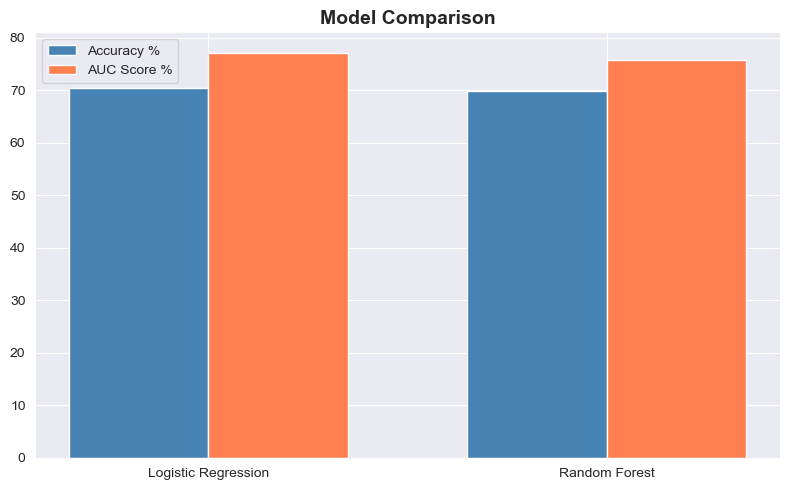

In [47]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [round(lr_acc*100, 2), round(rf_acc*100, 2)],
    'AUC Score': [round(lr_auc, 4), round(rf_auc, 4)]
})

print("📊 Model Comparison:")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, comparison['Accuracy'],
       width, label='Accuracy %', color='steelblue')
ax.bar(x + width/2, comparison['AUC Score']*100,
       width, label='AUC Score %', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/15_model_comparison.png', dpi=150)
plt.show()

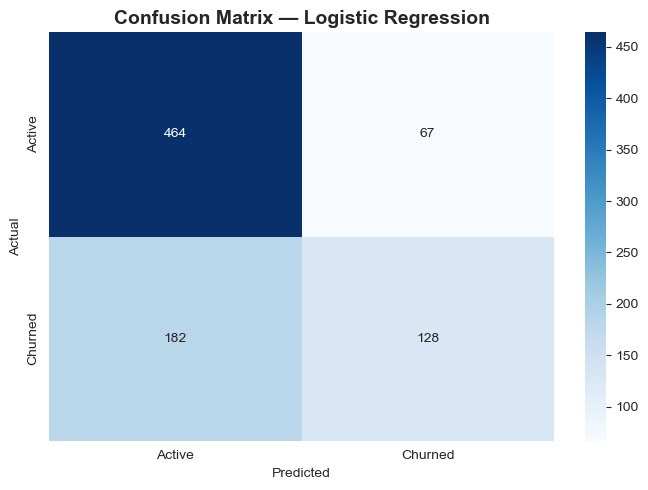

In [48]:
best_pred = rf_pred if rf_acc > lr_acc else lr_pred
best_name = 'Random Forest' if rf_acc > lr_acc else 'Logistic Regression'

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/16_confusion_matrix.png', dpi=150)
plt.show()

📊 Feature Importance:
  Feature  Importance
 Monetary    0.440993
  Recency    0.347153
Frequency    0.211854


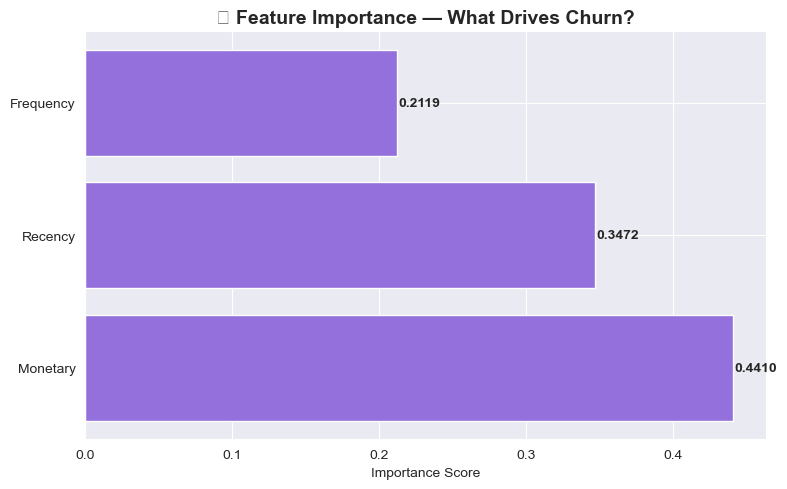

In [49]:
importance = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance:")
print(importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance['Feature'], importance['Importance'],
               color='mediumpurple')
for bar, val in zip(bars, importance['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold')
plt.title('🔍 Feature Importance — What Drives Churn?',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/17_feature_importance.png', dpi=150)
plt.show()

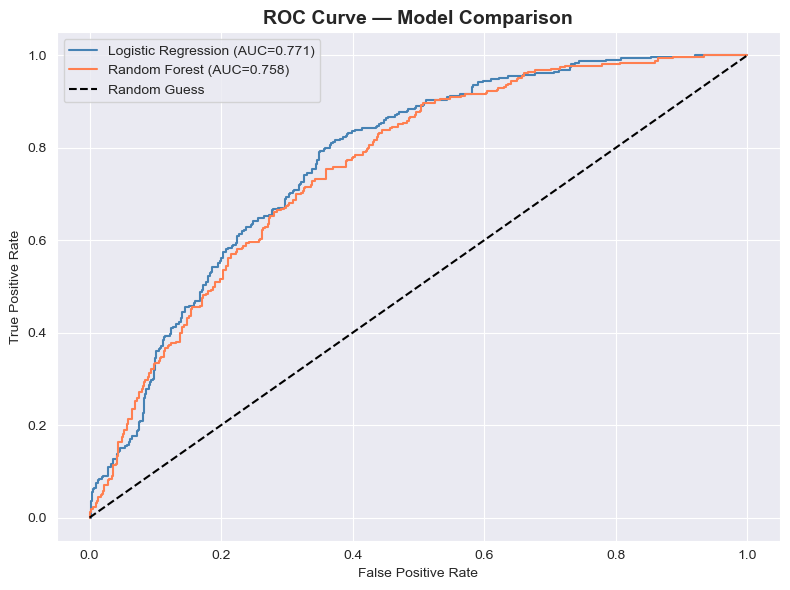

In [50]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={lr_auc:.3f})', color='steelblue')
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={rf_auc:.3f})', color='coral')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/18_roc_curve.png', dpi=150)
plt.show()

In [51]:
rfm_model['Churn_Predicted']   = rf.predict(rfm_model[features])
rfm_model['Churn_Probability'] = rf.predict_proba(
                                    rfm_model[features])[:,1].round(4)

rfm_model.to_csv('C:/Users/Yashwanth u/Desktop/Data_projects/retail-intelligence/cleaned/rfm_with_churn.csv', index=False)
print("✅ Predictions saved!")

high_risk = rfm_model[
    rfm_model['Churn_Probability'] > 0.8
].sort_values('Monetary', ascending=False)

print(f"\n🚨 High Risk Customers (Prob > 80%): {len(high_risk)}")
print(high_risk[['Customer ID','Recency','Frequency',
                  'Monetary','Churn_Probability']].head(10))

✅ Predictions saved!

🚨 High Risk Customers (Prob > 80%): 313
      Customer ID  Recency  Frequency  Monetary  Churn_Probability
1068        13902      282          4  33665.60             0.8012
92          12482      225         27  21941.72             0.8987
3604        17448      179         41  14448.67             0.9150
4039        18052      214          1  10877.18             0.8103
1199        14091      304          2   9530.08             0.8951
1085        13935      246          3   6116.92             0.8472
2296        15633      159         12   4144.07             0.9577
1179        14063      336          3   2769.90             0.8922
2145        15413      341          2   2285.30             0.9030
1868        15015      151         12   2214.87             0.8970


In [52]:
print("=" * 55)
print("🤖 ML CHURN PREDICTION — SUMMARY")
print("=" * 55)
print(f"Total Customers Analysed : {len(rfm_model)}")
print(f"Churned Customers        : {rfm_model['Churned'].sum()}")
print(f"Churn Rate               : {rfm_model['Churned'].mean()*100:.2f}%")
print(f"\nBest Model               : {best_name}")
print(f"Accuracy                 : {max(rf_acc, lr_acc)*100:.2f}%")
print(f"AUC Score                : {max(rf_auc, lr_auc):.4f}")
print(f"\nHigh Risk Customers      : {len(high_risk)}")
print(f"Top Feature              : {importance.iloc[0]['Feature']}")
print("=" * 55)

🤖 ML CHURN PREDICTION — SUMMARY
Total Customers Analysed : 4205
Churned Customers        : 1549
Churn Rate               : 36.84%

Best Model               : Logistic Regression
Accuracy                 : 70.39%
AUC Score                : 0.7714

High Risk Customers      : 313
Top Feature              : Monetary
